In [1]:
import unipercept as up
import seaborn as sns
import matplotlib.pyplot as plt

assets_info = up.data.sets.catalog.get_info("kitti-step")
assets_root = up.file_io.Path("./assets/testing/")

seq_id = "0001"

inputs_path = assets_root / "inputs" / seq_id
depths_path = assets_root / "truths" / "depths" / seq_id
panseg_path = assets_root / "truths" / "segmentations" / seq_id

assert inputs_path.exists(), inputs_path
assert depths_path.exists(), depths_path
assert panseg_path.exists(), panseg_path

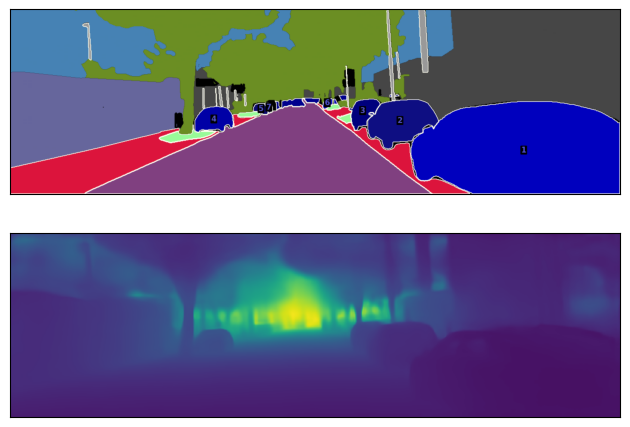

In [2]:
fig, ax = plt.subplots(2)

panseg = up.data.tensors.PanopticMap.read(
    next(panseg_path.glob("**/*")), assets_info, format="kitti"
)
up.render.draw_image_segmentation(panseg, assets_info, ax=ax[0])

depth = up.data.tensors.DepthMap.read(next(depths_path.glob("**/*")), format="tiff")
up.render.draw_image_depth(depth, assets_info, ax=ax[1])

fig.tight_layout()